In [1]:
import pandas as pd

df = pd.read_csv("Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\expanded_image_caption_file.csv")

print(df.head())
print(len(df))

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\sandesh lavshetty\AppData\Local\Temp\ipykernel_11612\2279034909.py:3: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\expanded_image_caption_file.csv")


  image_id                                            caption
0    1C1_1  A cut potato tuber showing mild potato tuber g...
1    1C1_1  A potato tuber cross-section exhibiting mild c...
2    1C1_1  A potato tuber affected by mild greening in th...
3    1C1_1  A cut potato tuber displaying mild green disco...
4    1C1_1  A potato tuber sample with mild greening near ...
9235


In [2]:
unique_images = df['image_id'].nunique()
print("Unique images:", unique_images)

Unique images: 1847


In [3]:
captions_per_image = df.groupby('image_id').size()

print("Average captions per image:", captions_per_image.mean())
print("Min captions:", captions_per_image.min())
print("Max captions:", captions_per_image.max())

Average captions per image: 5.0
Min captions: 5
Max captions: 5


In [4]:
df['caption_length'] = df['caption'].apply(lambda x: len(x.split()))

print("Average length:", df['caption_length'].mean())
print("Max length:", df['caption_length'].max())
print("Min length:", df['caption_length'].min())

Average length: 13.232051976177585
Max length: 19
Min length: 8


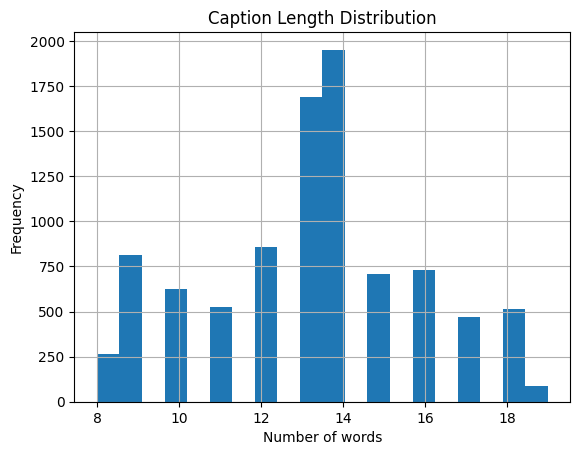

In [5]:
import matplotlib.pyplot as plt

df['caption_length'].hist(bins=20)
plt.title("Caption Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [6]:
from collections import Counter

all_words = []

for cap in df['caption']:
    words = cap.lower().split()
    all_words.extend(words)

vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 182


In [7]:
print(vocab.most_common(20))

[('a', 8923), ('tuber', 8654), ('potato', 7856), ('moderate', 3970), ('the', 3969), ('whole', 3963), ('of', 3682), ('with', 3231), ('rot', 2460), ('dry', 2450), ('internal', 2228), ('by', 2036), ('mild', 1965), ('and', 1876), ('exhibiting', 1768), ('soft', 1765), ('rot.', 1755), ('severe', 1738), ('showing', 1692), ('sample', 1658)]


In [8]:
def get_severity(caption):
    if "mild" in caption:
        return "mild"
    elif "moderate" in caption:
        return "moderate"
    elif "severe" in caption:
        return "severe"
    else:
        return "unknown"

df['severity'] = df['caption'].apply(get_severity)

In [9]:
print(df['severity'].value_counts())

severity
moderate    3970
mild        1965
severe      1738
unknown     1562
Name: count, dtype: int64


In [10]:
unknown_captions = df[df['severity'] == 'unknown']['caption']
print("Captions with unknown severity:")
print(unknown_captions)

Captions with unknown severity:
7516    Severe-stage soft rot characterized by widespr...
7517    Advanced external deterioration due to aggress...
7519    Whole tuber demonstrating advanced-stage surfa...
7521    Severe-stage soft rot characterized by widespr...
7522    Advanced external deterioration due to aggress...
                              ...                        
9230    A whole potato tuber exhibiting normal physiol...
9231    Healthy tuber with intact periderm and uniform...
9232    Absence of lesions, discoloration, or tissue d...
9233    Morphologically sound potato tuber with smooth...
9234    Disease-free control sample representing the h...
Name: caption, Length: 1562, dtype: object


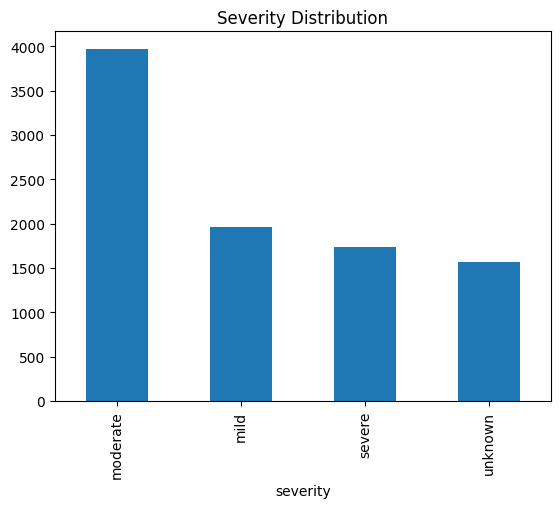

In [11]:
df['severity'].value_counts().plot(kind='bar')
plt.title("Severity Distribution")
plt.show()

In [12]:
unique_captions = df['caption'].nunique()
print("Unique captions:", unique_captions)
print("Total captions:", len(df))

Unique captions: 110
Total captions: 9235


In [13]:
import os

image_folder = "Potato_Tuber_Diseased_Caption_Dataset\\Potato_Tuber_Diseased_Caption_Dataset\\Images"

missing = []

for img in df['image_id'].unique():
    path = os.path.join(image_folder, img + ".jpg")
    
    if not os.path.exists(path):
        missing.append(img)
    
print("Missing images:", len(missing))
print("Missing image IDs:", missing)

Missing images: 1
Missing image IDs: ['1W2_71']


In [14]:
(df['image_id'] == "1W2_71").sum()

5

In [15]:
import pandas as pd
import pathlib

csv_path = pathlib.Path(r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\expanded_image_caption_file.csv")
df = pd.read_csv(csv_path)

# 1. rename column
df = df.rename(columns={"image_id": "file_name"})

# 2. add .jpg extension if it isn’t there
df["file_name"] = df["file_name"].astype(str) + ".jpg"

# 3. keep only the first caption for every image
df = df.drop_duplicates(subset=["file_name"], keep="first")

# 4. save as the name ImageFolder looks for
df.to_csv(csv_path.with_name("metadata.csv"), index=False)

0


Missing files: 0
[]


3. Common next steps



Replace the simple resize/crop with Albumentations or KerasCV for heavier augmentation.  
Tokenise captions if you want an encoder-decoder image-captioning model (transformers Blip, GIT, etc.).  
Split the dataset into train/validation (ds.train_test_split(0.1)).  
Push the processed dataset to the Hub so teammates can simply load_dataset("your-username/potato-tuber-torch").